Import Libraries

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
df=pd.read_csv("/content/drive/MyDrive/tech_job_market_2019_2026.csv")

In [113]:
df.shape

(115000, 28)

There are 115000 rows and 28 columns

In [114]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  object 
 1   company_name                  115000 non-null  object 
 2   company_type                  115000 non-null  object 
 3   sector                        115000 non-null  object 
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  object 
 6   job_role                      115000 non-null  object 
 7   seniority_level               115000 non-null  object 
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  object 
 11  primary_programming_language  92525 non-null   object 
 12  work_mode                     115000 non-nul

There are 4 float type,3 int type and 21 object type values

In [116]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [117]:
df.isnull().sum()

,0
job_id,0
company_name,0
company_type,0
sector,0
company_size_employees,0
hq_country,0
job_role,0
seniority_level,0
years_experience_min,0
years_experience_max,0


In [118]:
df.isnull().sum().sum()

np.int64(87962)

There are 87962 missing values

In [119]:
df.duplicated().sum()

np.int64(1193)

There is 1193 duplicated row

There are many columns to study, so we are going to analyze top 15-20 columns which give more insights and are more relevent to data

In [120]:
structure = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Non-Null Count': df.notnull().sum().values,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Unique Values': df.nunique(dropna=False).values
})


In [121]:
print (structure)

                          Column Data Type  Non-Null Count  Missing Count  \
0                         job_id    object          115000              0   
1                   company_name    object          115000              0   
2                   company_type    object          115000              0   
3                         sector    object          115000              0   
4         company_size_employees     int64          115000              0   
5                     hq_country    object          115000              0   
6                       job_role    object          115000              0   
7                seniority_level    object          115000              0   
8           years_experience_min     int64          115000              0   
9           years_experience_max     int64          115000              0   
10           required_tech_stack    object          115000              0   
11  primary_programming_language    object           92525          22475   

In [122]:
print("Unique values in salary_min_usd:")
print(df['salary_min_usd'].unique()[:30])

print("\nUnique values in salary_max_usd:")
print(df['salary_max_usd'].unique()[:30])

Unique values in salary_min_usd:
['-1' nan '238800.0' '96300.0' '$186,800' '33100.0' '87400.0' '131100.0'
 '114500.0' '42500.0' '72300.0' '115800.0' '126200.0' '226200.0' '82600.0'
 '133400.0' '130900.0' '120600.0' '96900.0' '174800.0' '108600.0'
 '40,600 USD' '250800.0' '60400.0' '54100.0' '152700.0' '206000.0'
 '183500.0' '123900.0' '189200.0']

Unique values in salary_max_usd:
['-1' nan '274700.0' '104000.0' '245400.0' '38500.0' '98100.0' '103900.0'
 '139700.0' '47600.0' '84700.0' '152400.0' '144300.0' '275000.0'
 '106100.0' '146900.0' '172500.0' '157700.0' '117400.0' '189900.0'
 '129300.0' '49400.0' '288300.0' '67800.0' '65100.0' '166400.0' '246100.0'
 '235700.0' '143800.0' '226100.0']


In [123]:
print("Sample salary_min_usd values:")
print(df['salary_min_usd'].sample(20, random_state=42).tolist())

print("\nSample salary_max_usd values:")
print(df['salary_max_usd'].sample(20, random_state=42).tolist())

Sample salary_min_usd values:
['107900.0', '76000.0', '269500.0', '160100.0', '164900.0', '151900.0', '95700.0', '119800.0', '75000.0', '104300.0', '120900.0', '79800.0', '137600.0', '75300.0', '112100.0', '85700.0', '76500.0', '59800.0', '213500.0', '80600.0']

Sample salary_max_usd values:
['138700.0', '95000.0', '357800.0', '181200.0', '181900.0', '174100.0', '125000.0', '129700.0', '85100.0', '116100.0', '151000.0', '100600.0', '183300.0', '90800.0', '126500.0', '115600.0', '88200.0', '75500.0', '259900.0', '102500.0']


DATA CLEANING

In [124]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

Before removing duplicates: (115000, 28)
After removing duplicates: (113807, 28)


In [125]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


CLEANING SALARY

In [126]:
def clean_salary(series):
    return (
        series
        .astype('string')
        .str.replace(r'[$,]', '', regex=True)
        .str.replace(r'\s*USD\s*', '', regex=True, case=False)
        .str.strip()
        .replace(['', 'nan', '-1', '-1-1'], np.nan)
        .pipe(pd.to_numeric, errors='coerce')
    )

df['salary_min_usd'] = clean_salary(df['salary_min_usd'])
df['salary_max_usd'] = clean_salary(df['salary_max_usd'])

In [127]:
print(df[['salary_min_usd', 'salary_max_usd']].dtypes)
print(df[['salary_min_usd', 'salary_max_usd']].isnull().sum())

salary_min_usd    Float64
salary_max_usd    Float64
dtype: object
salary_min_usd    4689
salary_max_usd    4689
dtype: int64


CONVERTING DATES PROPERLY

In [128]:
date_columns = [
    'posting_date',
    'application_deadline',
    'date_position_filled'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [129]:
df[date_columns].dtypes

,0
posting_date,datetime64[ns]
application_deadline,datetime64[ns]
date_position_filled,datetime64[ns]


CLEANING CATEGORICAL VARIABLES

In [130]:
df['visa_sponsorship_offered'].value_counts(dropna=False)

,count
visa_sponsorship_offered,
0,19625
False,19555
N,19553
No,19346
Yes,9001
True,8937
1,8897
Y,8893


In [131]:
df['visa_sponsorship_offered'] = (
    df['visa_sponsorship_offered']
    .astype('string')
    .str.strip()
    .str.lower()
    .replace({
        'y': 'yes',
        'n': 'no'
    })
)

In [132]:
df['visa_sponsorship_offered'].value_counts(dropna=False)

,count
visa_sponsorship_offered,
no,38899
0,19625
false,19555
yes,17894
true,8937
1,8897


CHECKING LOGICAL ERRORS

In [65]:
print(
    "Invalid experience ranges:",
    (df['years_experience_max'] < df['years_experience_min']).sum()
)

print(
    "Invalid salary ranges:",
    (df['salary_max_usd'] < df['salary_min_usd']).sum()
)

print(
    "Accepted offers > extended offers:",
    (df['offers_accepted'] > df['offers_extended']).sum()
)

print(
    "Deadline before posting:",
    (df['application_deadline'] < df['posting_date']).sum()
)

print(
    "Position filled before posting:",
    (df['date_position_filled'] < df['posting_date']).sum()
)

Invalid experience ranges: 315
Invalid salary ranges: 445
Accepted offers > extended offers: 591
Deadline before posting: 0
Position filled before posting: 439


FIXING THE LOGICAL ERRORS

In [137]:
invalid_exp = df['years_experience_max'] < df['years_experience_min']

df.loc[
    invalid_exp,
    ['years_experience_min', 'years_experience_max']
] = np.nan

In [138]:
invalid_salary = df['salary_max_usd'] < df['salary_min_usd']

df.loc[
    invalid_salary,
    ['salary_min_usd', 'salary_max_usd']
] = np.nan

In [139]:
invalid_offers = (
    df['offers_accepted'] > df['offers_extended']
)

df.loc[
    invalid_offers,
    ['offers_extended', 'offers_accepted']
] = np.nan

In [140]:
invalid_fill = (
    df['date_position_filled'] < df['posting_date']
)

df.loc[
    invalid_fill,
    'date_position_filled'
] = pd.NaT

FOR MISSING VALUES

In [141]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0]
missing = missing.sort_values('Missing %', ascending=False)

missing

,Missing Count,Missing %
date_position_filled,25953,22.80
job_location_city,24847,21.83
primary_programming_language,22263,19.56
application_deadline,11275,9.91
salary_min_usd,5134,4.51
salary_max_usd,5134,4.51
number_of_applicants,1103,0.97
offers_accepted,919,0.81
offers_extended,919,0.81
number_of_interview_rounds,434,0.38


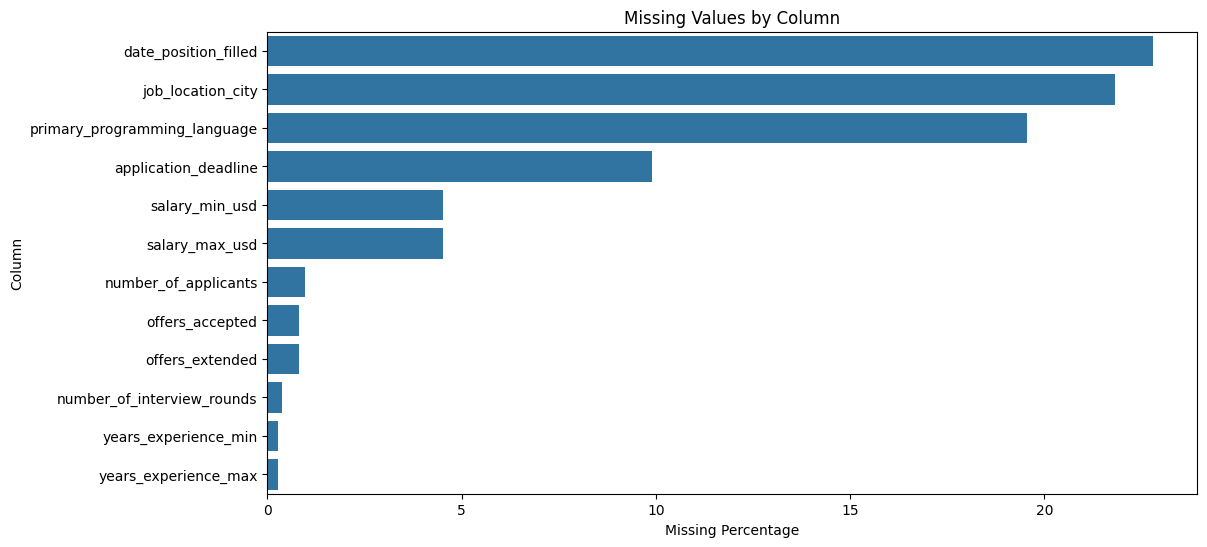

In [142]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing['Missing %'],
    y=missing.index
)

plt.title('Missing Values by Column')
plt.xlabel('Missing Percentage')
plt.ylabel('Column')
plt.show()

In [143]:
df['job_location_city'] = df['job_location_city'].fillna('Unknown')

In [144]:
df['primary_programming_language'] = (
    df['primary_programming_language']
    .fillna('Unknown')
)

UNIVARIATE ANALYSIS

In [68]:
import warnings
warnings.filterwarnings('ignore')

CATEGORICAL VARIABLES

COMPANY_TYPE

In [69]:
print(df['company_type'].value_counts(dropna=False))

company_type
MNC           55501
Mid-size      20079
Unicorn       15921
FAANG-tier    15783
Startup        6523
Name: count, dtype: int64


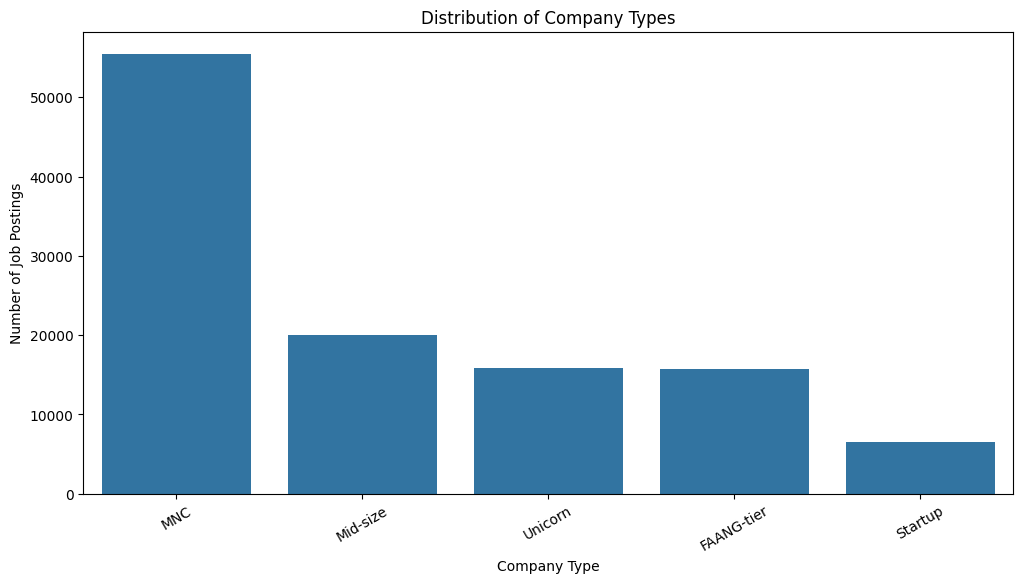

In [70]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    x='company_type',
    order=df['company_type'].value_counts().index
)

plt.title('Distribution of Company Types')
plt.xlabel('Company Type')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=30)
plt.show()

The distribution shows how job postings are distributed across different company types. This helps identify which types of organizations contribute most to the job market represented in the dataset and here it is MNC.

SECTOR

In [71]:
print(df['sector'].value_counts(dropna=False))

sector
E-commerce       16491
HealthTech       15125
Fintech          13008
EdTech           11414
Social/AdTech     8938
AI/ML             8803
SaaS              8522
Crypto/Web3       7954
Cloud/Infra       6502
Cybersecurity     5677
Logistics         5231
Gaming            4985
e-commerce         172
healthtech         145
fintech            139
edtech             125
social/adtech       99
saas                88
crypto/web3         87
ai/ml               87
cloud/infra         60
gaming              57
logistics           49
cybersecurity       49
Name: count, dtype: int64


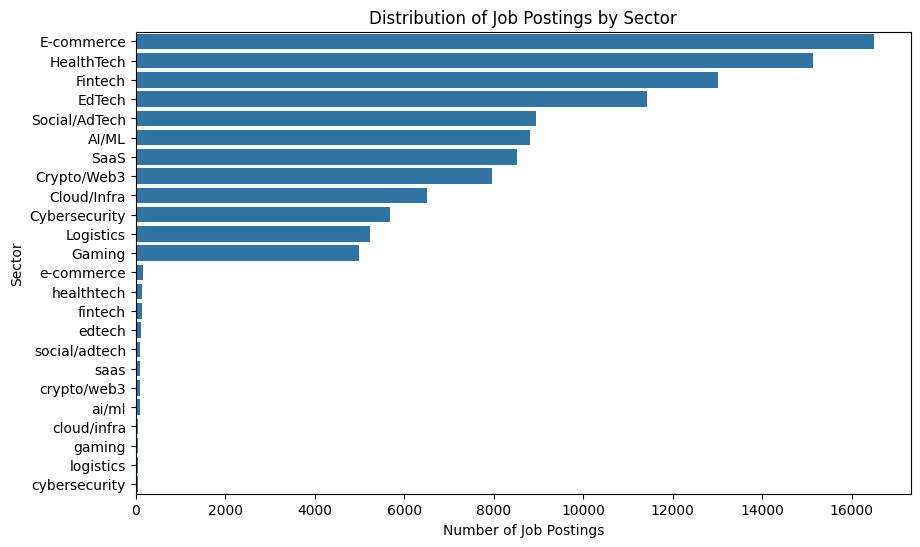

In [72]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y='sector',
    order=df['sector'].value_counts().index
)

plt.title('Distribution of Job Postings by Sector')
plt.xlabel('Number of Job Postings')
plt.ylabel('Sector')
plt.show()

The sector distribution highlights the industries generating the highest number of job postings and provides an overview of the composition of the technology job market and here it is E-commerce.

JOB_ROLE

In [73]:
top_roles = df['job_role'].value_counts().head(15)

print(top_roles)

job_role
Backend Engineer             5939
Embedded Systems Engineer    5912
QA Engineer                  5854
Software Engineer            5820
Frontend Engineer            5786
Mobile Engineer (iOS)        5734
Full Stack Engineer          5726
Mobile Engineer (Android)    5691
DevOps Engineer              3571
Infrastructure Engineer      3550
Cloud Engineer               3520
Site Reliability Engineer    3508
Platform Engineer            3508
Machine Learning Engineer    3094
Data Analyst                 3061
Name: count, dtype: int64


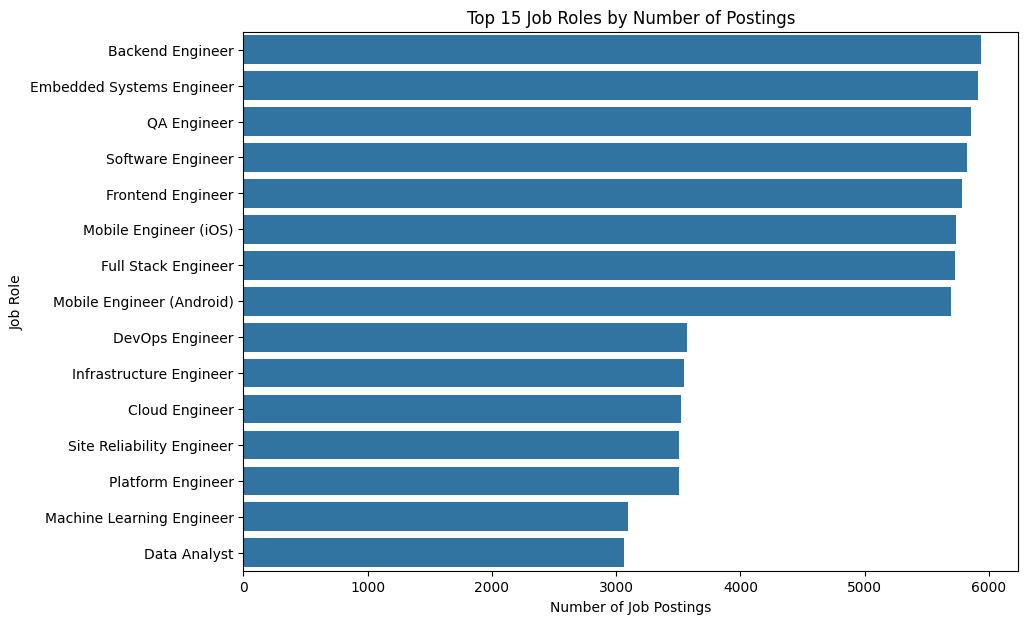

In [74]:
plt.figure(figsize=(10, 7))
sns.barplot(
    x=top_roles.values,
    y=top_roles.index
)

plt.title('Top 15 Job Roles by Number of Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Role')
plt.show()

The top job roles reveal which technical and technology-related positions occur most frequently in the dataset. Limiting the visualization to the top 15 roles keeps the distribution readable while the complete frequency table remains available for analysis and here it is backened engineer.

SENIORITY LEVEL

In [75]:
print(df['seniority_level'].value_counts(dropna=False))

seniority_level
Mid          38686
Entry        28322
Senior       22776
Lead         10366
Intern        9157
Principal     4500
Name: count, dtype: int64


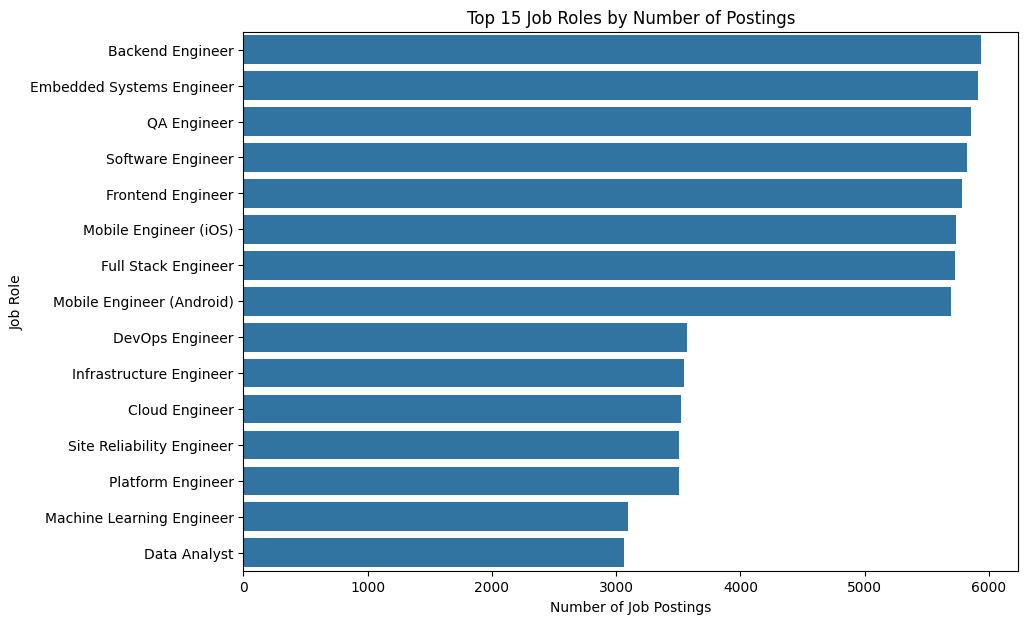

In [76]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_roles.values,
    y=top_roles.index
)

plt.title('Top 15 Job Roles by Number of Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Role')
plt.show()

he seniority-level distribution shows that job postings are spread across different experience levels, with some seniority categories having noticeably more opportunities than others. This indicates that the demand for tech professionals is not uniform across career stages. Backened Engineerlevel has the highest number of job postings, indicating stronger demand for professionals at this career stage.”

WORK_MODE

In [145]:
print(df['work_mode'].value_counts(dropna=False))

work_mode
Hybrid            48423
Remote            31986
Onsite            26470
HYBRID             1487
hybrid             1333
remote              593
Work From Home      560
WFH                 556
REMOTE              548
ONSITE              472
onsite              463
In-office           461
On-site             455
Name: count, dtype: int64


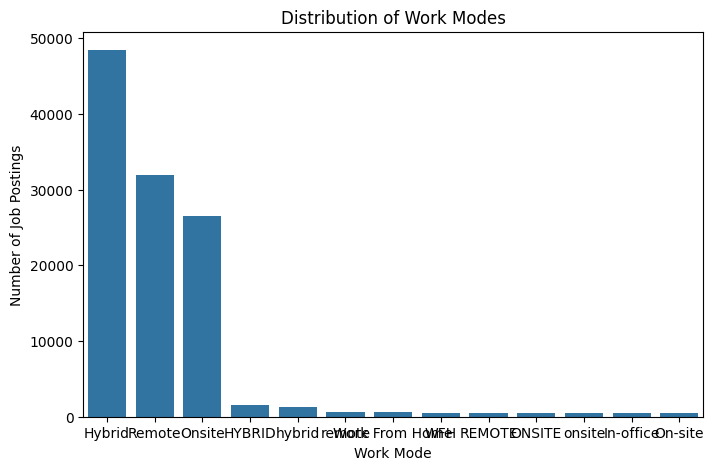

In [79]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='work_mode',
    order=df['work_mode'].value_counts().index
)

plt.title('Distribution of Work Modes')
plt.xlabel('Work Mode')
plt.ylabel('Number of Job Postings')
plt.show()

The work-mode distribution shows the availability of jobs across Remote, Hybrid, and On-site arrangements. The graph helps identify the dominant working arrangement in the tech job market.Hybrid s the most common work arrangement, suggesting that this mode is more prevalent in the dataset.”

POSITION STATUS

In [80]:
print(df['position_status'].value_counts(dropna=False))

position_status
Filled       90118
Open         10051
Cancelled     7970
Withdrawn     5668
Name: count, dtype: int64


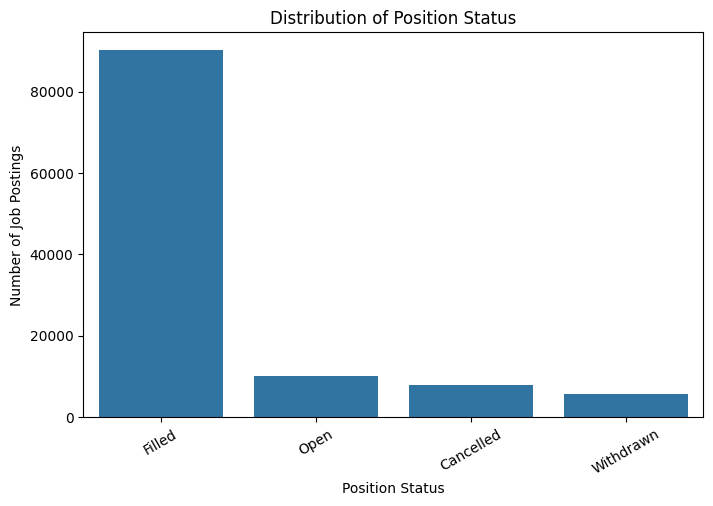

In [81]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='position_status',
    order=df['position_status'].value_counts().index
)

plt.title('Distribution of Position Status')
plt.xlabel('Position Status')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=30)
plt.show()

The position status distribution shows the proportion of job postings that are filled, open, or closed. This helps understand the overall hiring outcome and the current status of opportunities in the dataset.

“FILLED category has the highest number of postings, indicating that most job postings in the dataset fall under this status.”

VISA SPONSORSHIP OFFERED

In [147]:
print(df['visa_sponsorship_offered'].value_counts(dropna=False))

visa_sponsorship_offered
no       38899
0        19625
false    19555
yes      17894
true      8937
1         8897
Name: count, dtype: Int64


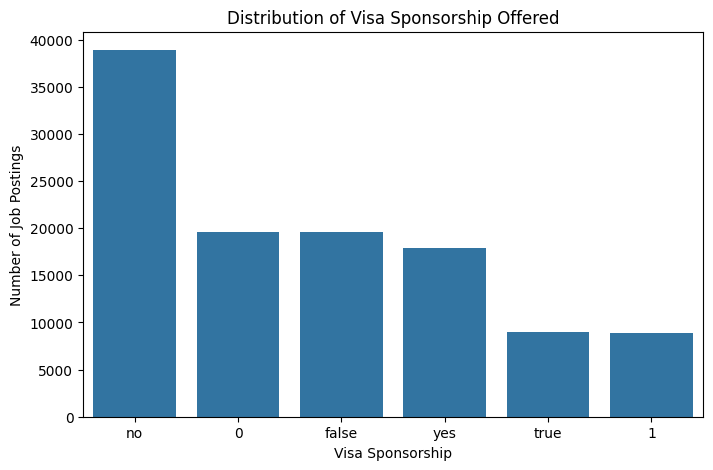

In [148]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='visa_sponsorship_offered',
    order=df['visa_sponsorship_offered'].value_counts().index
)

plt.title('Distribution of Visa Sponsorship Offered')
plt.xlabel('Visa Sponsorship')
plt.ylabel('Number of Job Postings')
plt.show()

The visa sponsorship distribution shows whether companies offer visa sponsorship for the advertised positions. The graph indicates that visa sponsorship is available for only a portion of the job postings, while the remaining positions do not offer sponsorship.“The majority of job postings do not offer visa sponsorship, indicating that sponsorship opportunities are relatively limited in the dataset.”

NUMERICAL VARIABLE

COMPANY SIZE EMPLOYEE

In [149]:
df['company_size_employees'].describe()

,company_size_employees
count,113807.000000
mean,105407.621552
std,102128.678701
min,10.000000
25%,6044.500000
50%,88378.000000
75%,169835.500000
max,488674.000000


HISTOGRAM

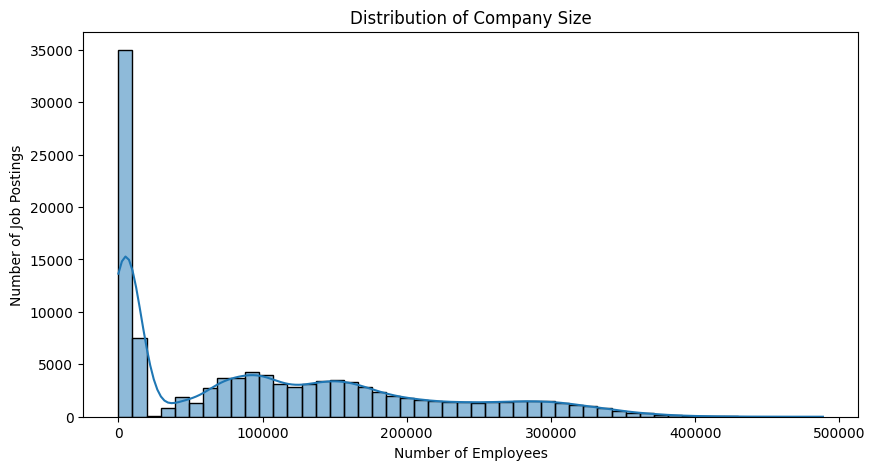

In [150]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['company_size_employees'],
    bins=50,
    kde=True
)

plt.title('Distribution of Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('Number of Job Postings')
plt.show()

The histogram shows the distribution of company sizes in the dataset. It helps identify where most companies fall in terms of employee count and whether the distribution is concentrated around smaller or larger organizations.

Conclusion: The distribution of company size is right-skewed, indicating that most job postings come from relatively smaller or medium-sized companies, while a smaller number of postings are associated with very large companies.

BOXPLOT

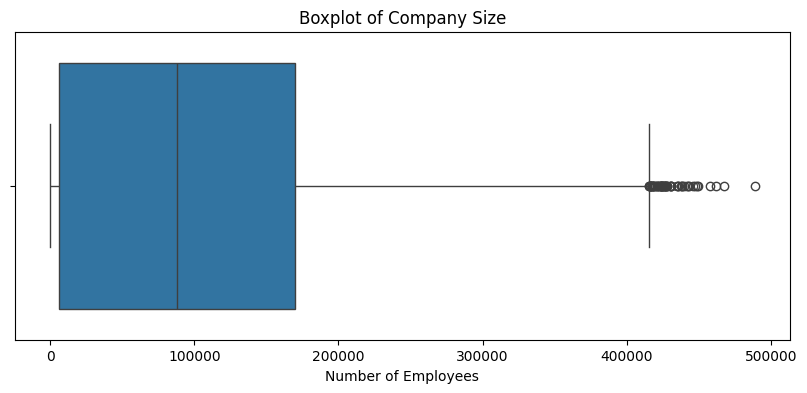

In [151]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['company_size_employees'])

plt.title('Boxplot of Company Size')
plt.xlabel('Number of Employees')
plt.show()

The boxplot shows the median, spread, and potential outliers in company size. The presence of points beyond the whiskers indicates that some companies have exceptionally large employee counts compared with the majority.

MINIMUM EXPERIENCE REQUIRED

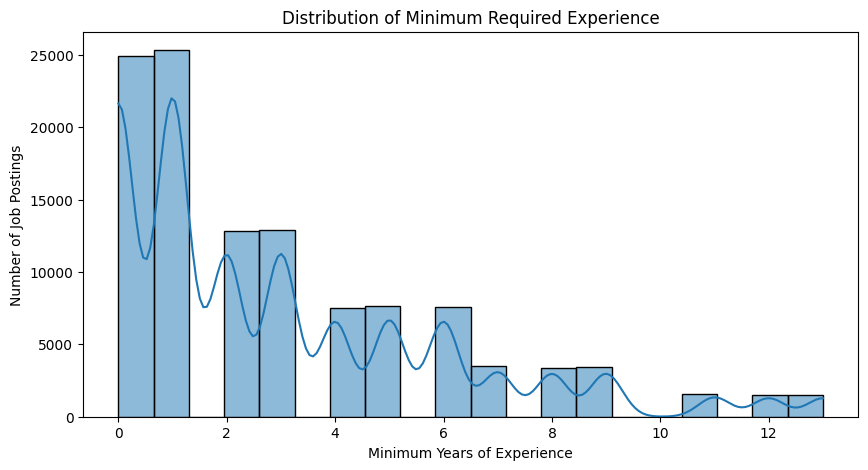

In [153]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['years_experience_min'],
    bins=20,
    kde=True
)

plt.title('Distribution of Minimum Required Experience')
plt.xlabel('Minimum Years of Experience')
plt.ylabel('Number of Job Postings')
plt.show()

The distribution of required years of experience shows that most job postings require relatively low to moderate experience, while fewer postings require very high experience. The distribution helps identify the common experience requirements in the tech job market.

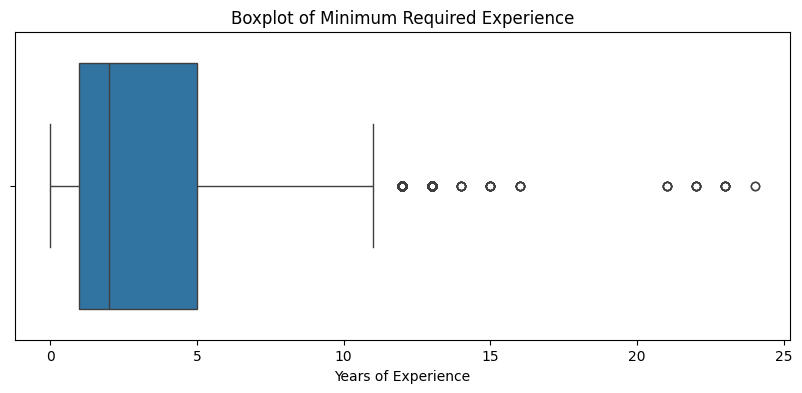

In [88]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['years_experience_min'])

plt.title('Boxplot of Minimum Required Experience')
plt.xlabel('Years of Experience')
plt.show()

The boxplot shows the median and spread of required experience. Some observations may appear as potential outliers, representing positions requiring unusually high experience. These should not be removed unless they are logically invalid.

NUMBER OF APPLICANTS

In [165]:
df['number_of_applicants'].describe()

,number_of_applicants
count,112704.000000
mean,181.779112
std,437.798085
min,-5.000000
25%,62.000000
50%,119.000000
75%,213.000000
max,36816.000000


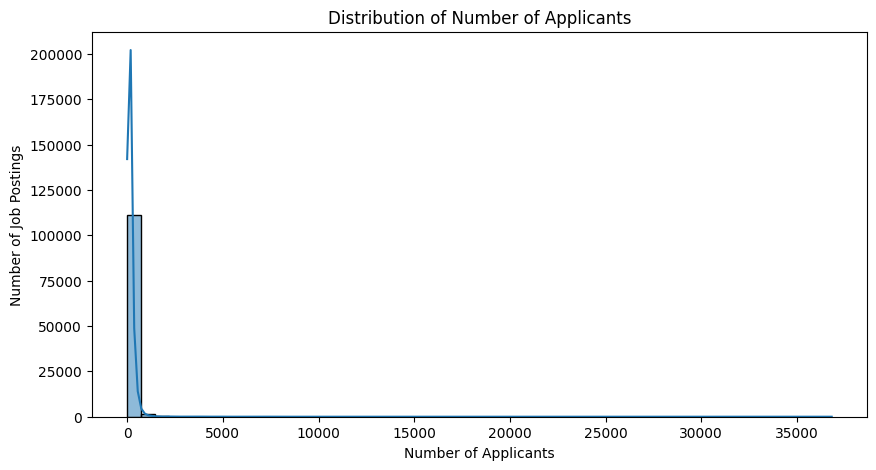

In [166]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['number_of_applicants'].dropna(),
    bins=50,
    kde=True
)

plt.title('Distribution of Number of Applicants')
plt.xlabel('Number of Applicants')
plt.ylabel('Number of Job Postings')
plt.show()

The distribution of applicants shows how the number of applications varies across job postings. The distribution is concentrated around lower applicant counts, with some postings receiving considerably more applications.

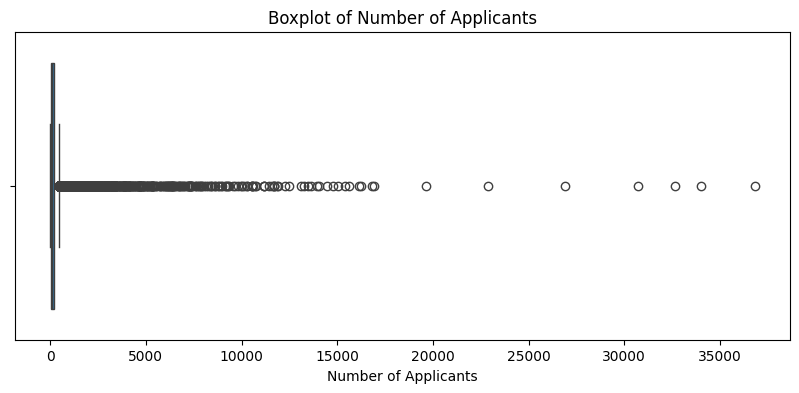

In [167]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['number_of_applicants'])

plt.title('Boxplot of Number of Applicants')
plt.xlabel('Number of Applicants')
plt.show()

The boxplot shows considerable variation in the number of applicants and identifies potential high-value outliers. These extreme values may represent highly popular job postings and should not be removed automatically.

NUMBER OF INTERVIEW ROUNDS

In [157]:
df['number_of_interview_rounds'].describe()

,number_of_interview_rounds
count,113373.000000
mean,3.307525
std,1.418054
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,8.000000


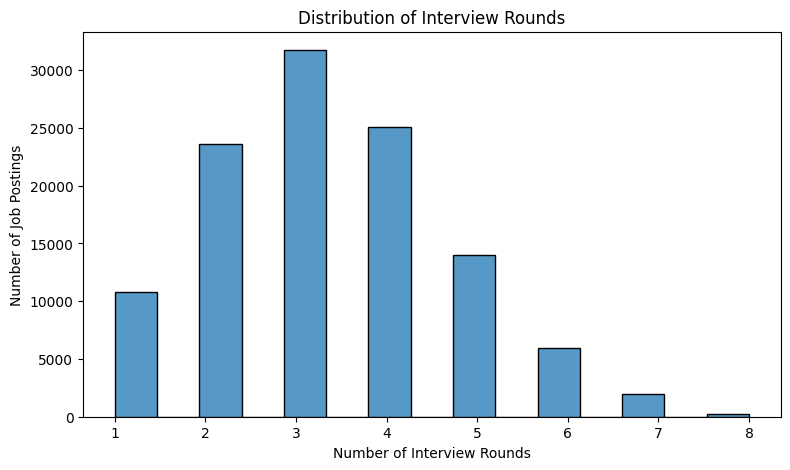

In [158]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df['number_of_interview_rounds'].dropna(),
    bins=15,
    kde=False
)

plt.title('Distribution of Interview Rounds')
plt.xlabel('Number of Interview Rounds')
plt.ylabel('Number of Job Postings')
plt.show()

OFFERS DATE

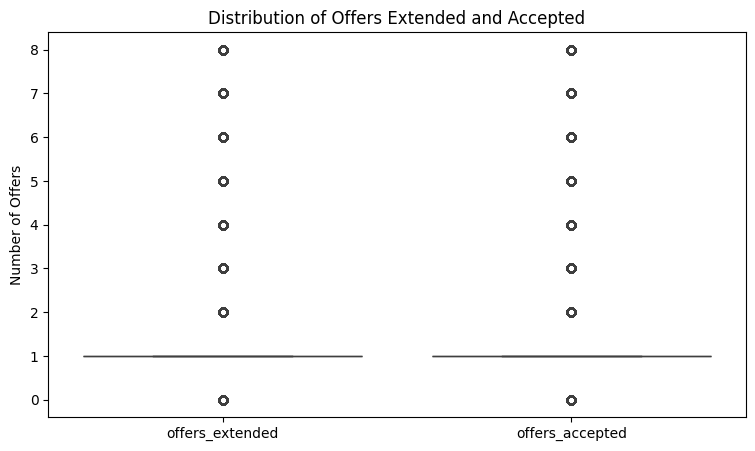

In [159]:
offers_data = df[
    ['offers_extended', 'offers_accepted']
].melt(
    var_name='Offer Metric',
    value_name='Number of Offers'
)
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=offers_data,
    x='Offer Metric',
    y='Number of Offers'
)

plt.title('Distribution of Offers Extended and Accepted')
plt.xlabel('')
plt.ylabel('Number of Offers')
plt.show()

In [95]:
df[
    ['salary_min_usd', 'salary_max_usd']
].describe()

,salary_min_usd,salary_max_usd
count,109118.0,109118.0
mean,115425.432101,142646.958339
std,57020.394161,91209.243103
min,1700.0,15900.0
25%,76500.0,92700.0
50%,105900.0,128700.0
75%,146100.0,177800.0
max,531800.0,3552000.0


MINIMUM SALARY

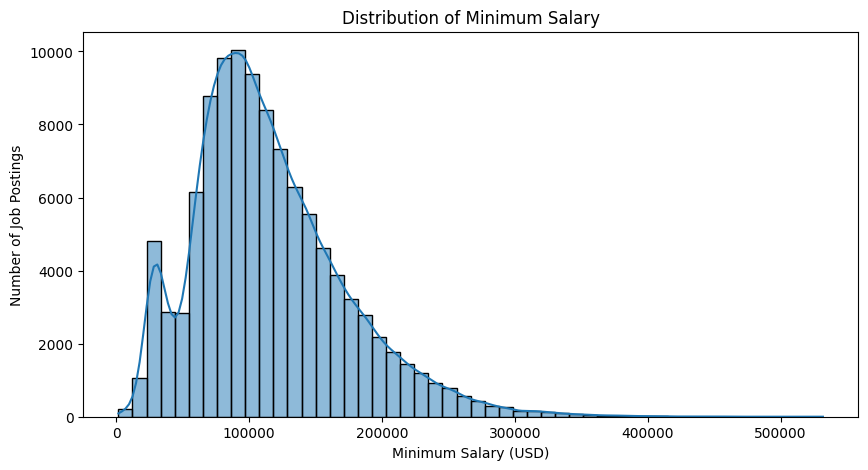

In [160]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['salary_min_usd'].dropna(),
    bins=50,
    kde=True
)

plt.title('Distribution of Minimum Salary')
plt.xlabel('Minimum Salary (USD)')
plt.ylabel('Number of Job Postings')
plt.show()

The minimum salary distribution shows the range of starting salaries offered across job postings. Most salaries are concentrated within a particular range, while some positions offer substantially higher minimum salaries.

MAXIMUM SALARY

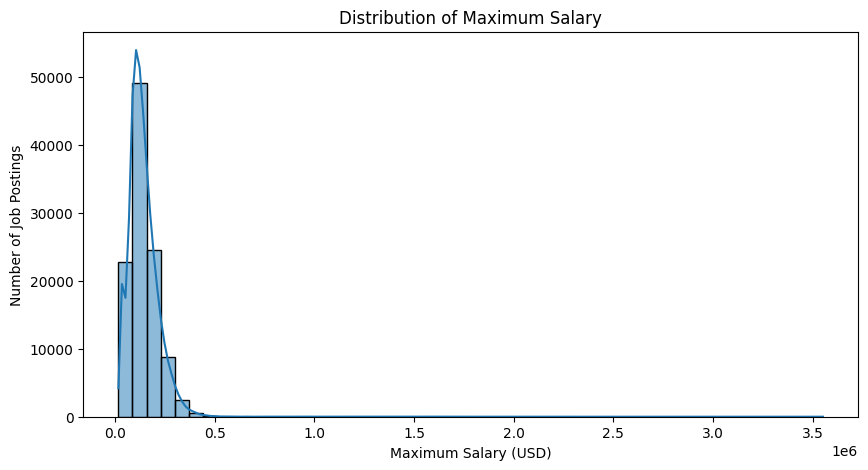

In [168]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['salary_max_usd'].dropna(),
    bins=50,
    kde=True
)

plt.title('Distribution of Maximum Salary')
plt.xlabel('Maximum Salary (USD)')
plt.ylabel('Number of Job Postings')
plt.show()

The maximum salary distribution shows the variation in the upper salary range offered by companies. Most job postings fall within a common salary range, while a smaller number offer considerably higher maximum salaries.

TOP LANGUAGES

In [169]:
top_languages = df['primary_programming_language'].value_counts().head(15)

print(top_languages)

primary_programming_language
Unknown       22811
Python        19209
Go            14503
Bash           5904
Java           5864
JavaScript     5810
Kotlin         5739
C++            5730
TypeScript     5718
Swift          5716
Scala          4449
R              4431
SQL            4386
C              3007
TBD             530
Name: count, dtype: int64


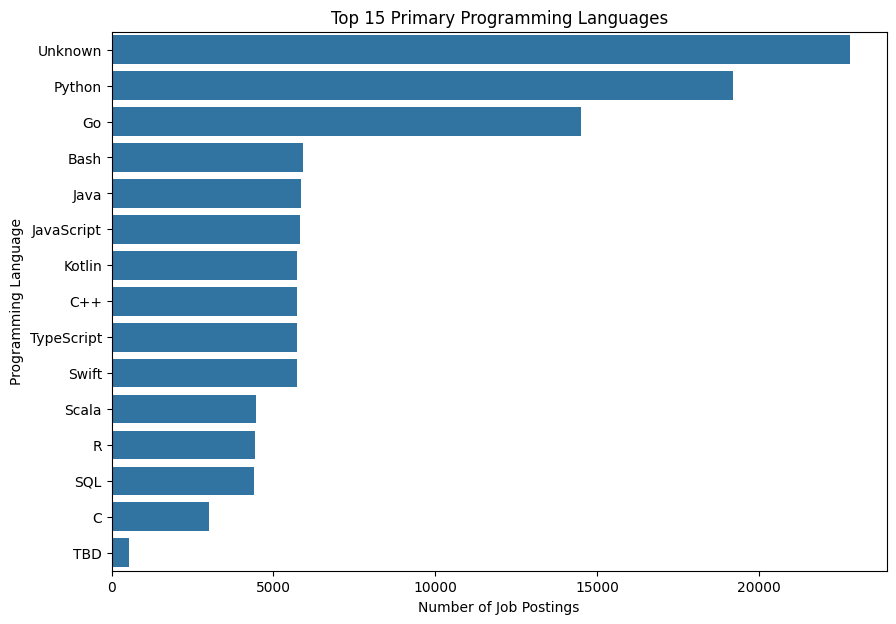

In [170]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_languages.values,
    y=top_languages.index
)

plt.title('Top 15 Primary Programming Languages')
plt.xlabel('Number of Job Postings')
plt.ylabel('Programming Language')
plt.show()

HEATMAP: TO FIND CO-RELATION

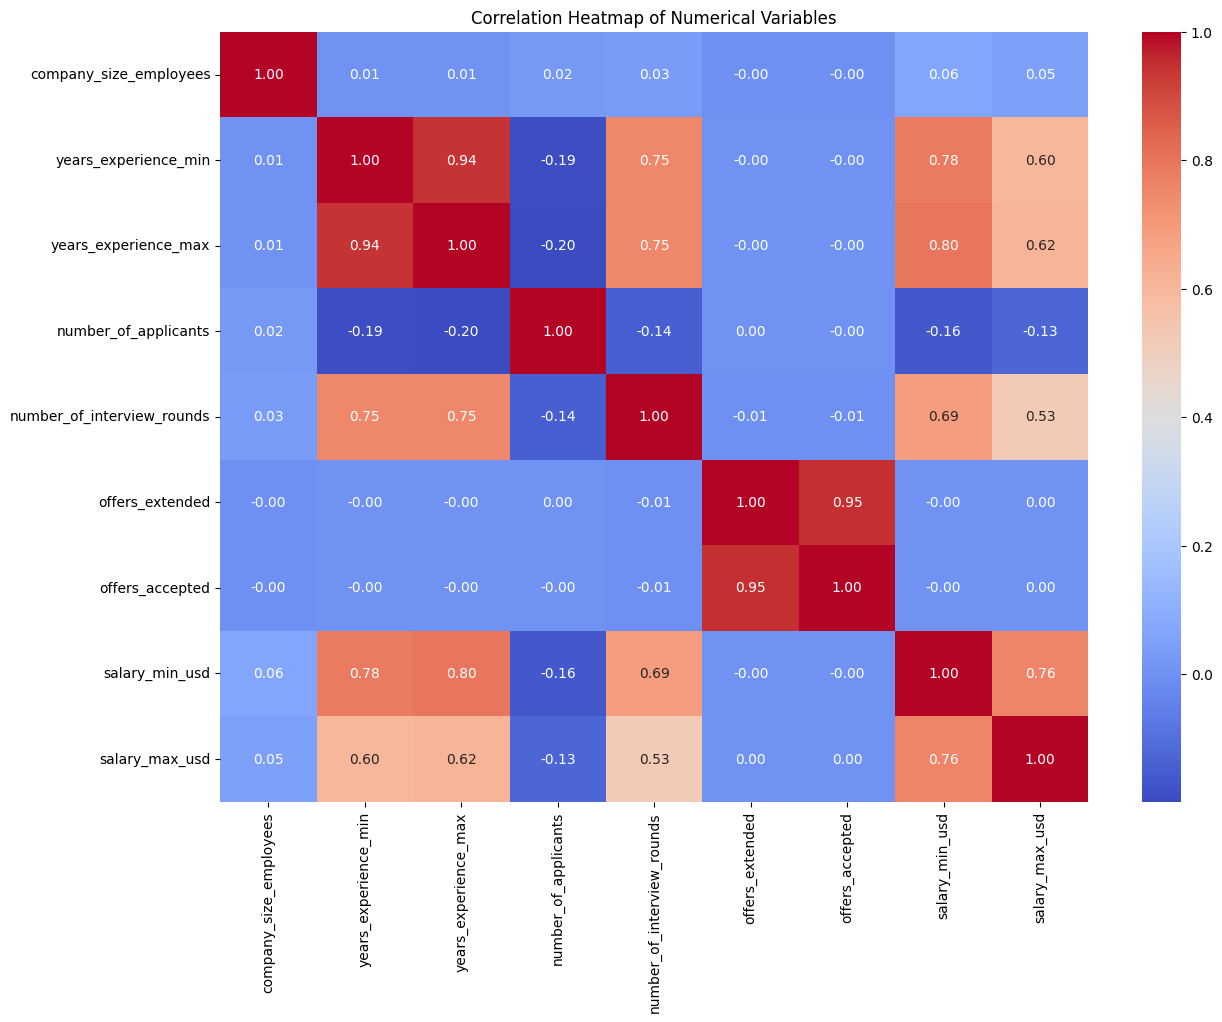

In [171]:
numeric_cols = df.select_dtypes(include=np.number).columns

corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

BIVARIATE ANALYSIS

Work Mode vs Salary

In [101]:
df[['salary_min_usd', 'salary_max_usd']].head(20)

,salary_min_usd,salary_max_usd
0,<NA>,<NA>
1,<NA>,<NA>
2,238800.0,274700.0
3,96300.0,104000.0
4,186800.0,245400.0
5,33100.0,38500.0
6,87400.0,98100.0
7,131100.0,103900.0
8,114500.0,139700.0
9,42500.0,47600.0


In [172]:
df['avg_salary'] = df[['salary_min_usd', 'salary_max_usd']].mean(axis=1)

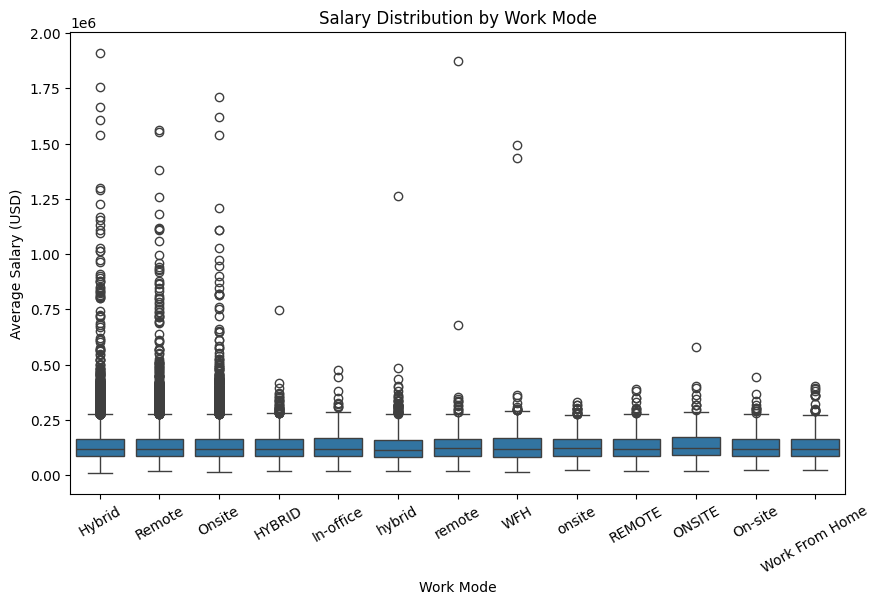

In [173]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='work_mode', y='avg_salary')

plt.title('Salary Distribution by Work Mode')
plt.xlabel('Work Mode')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=30)

plt.show()

### Observation

The boxplot compares salary distributions across different work modes.
The median salary and overall spread vary across work modes, while several
outliers can also be observed. The groupby summary provides the numerical
comparison of the salary distributions.

seniority level vs salary

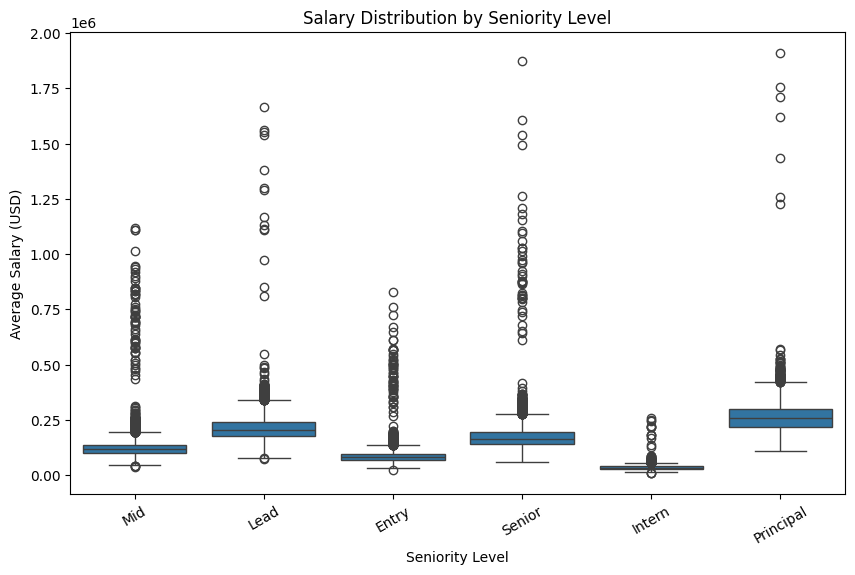

In [108]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='seniority_level', y='avg_salary')

plt.title('Salary Distribution by Seniority Level')
plt.xlabel('Seniority Level')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=30)

plt.show()

In [109]:
df.groupby('seniority_level')['avg_salary'].agg(
    ['count', 'mean', 'median']
).round(2).sort_values('median', ascending=False)

,count,mean,median
seniority_level,,,
Principal,3977,266645.92,256950.0
Lead,9212,212854.29,205150.0
Senior,22042,172597.74,165625.0
Mid,37517,122514.41,117700.0
Entry,27481,85347.11,81800.0
Intern,8889,35179.53,33850.0


### Observation

Salary distribution was compared across different seniority levels.
The median salary and salary spread show how compensation varies with
experience and seniority.

work mode vs number of applicants

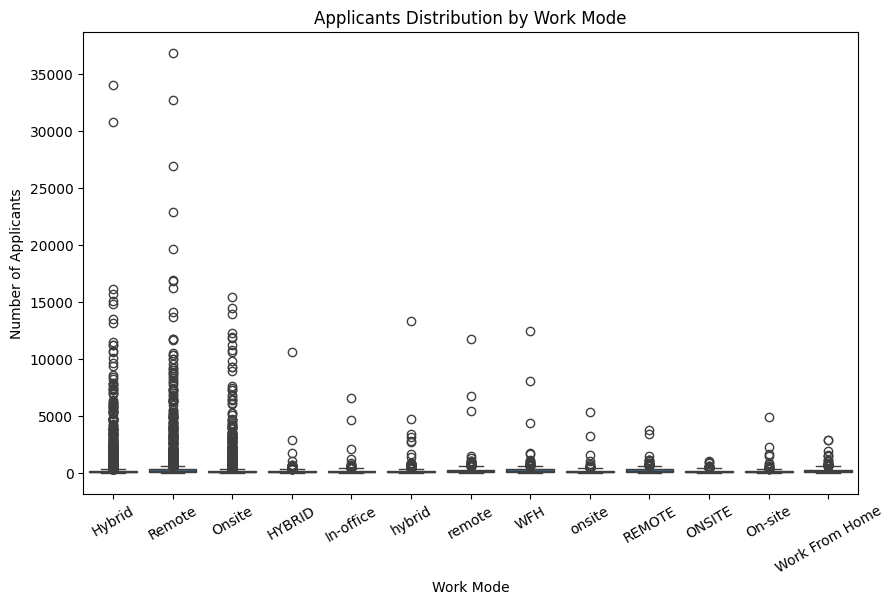

In [110]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='work_mode', y='number_of_applicants')

plt.title('Applicants Distribution by Work Mode')
plt.xlabel('Work Mode')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=30)

plt.show()

In [ ]:
df.groupby('work_mode')['number_of_applicants'].agg(
    ['count', 'mean', 'median', 'max']
).round(2)

,count,mean,median,max
work_mode,,,,
HYBRID,1496,145.22,102.5,10584.0
Hybrid,48478,153.12,103.0,34034.0
In-office,462,165.61,97.0,6562.0
ONSITE,469,139.61,101.0,1071.0
On-site,455,148.39,101.0,4921.0
Onsite,26482,156.91,105.0,15392.0
REMOTE,551,234.37,165.0,3712.0
Remote,32002,245.19,166.0,36816.0
WFH,552,262.63,168.0,12474.0


### Observation

Salary distribution was compared across different seniority levels.
The median salary and salary spread show how compensation varies with
experience and seniority.

sector vs salary

In [ ]:
top_sectors = df['sector'].value_counts().head(10).index

sector_df = df[df['sector'].isin(top_sectors)]

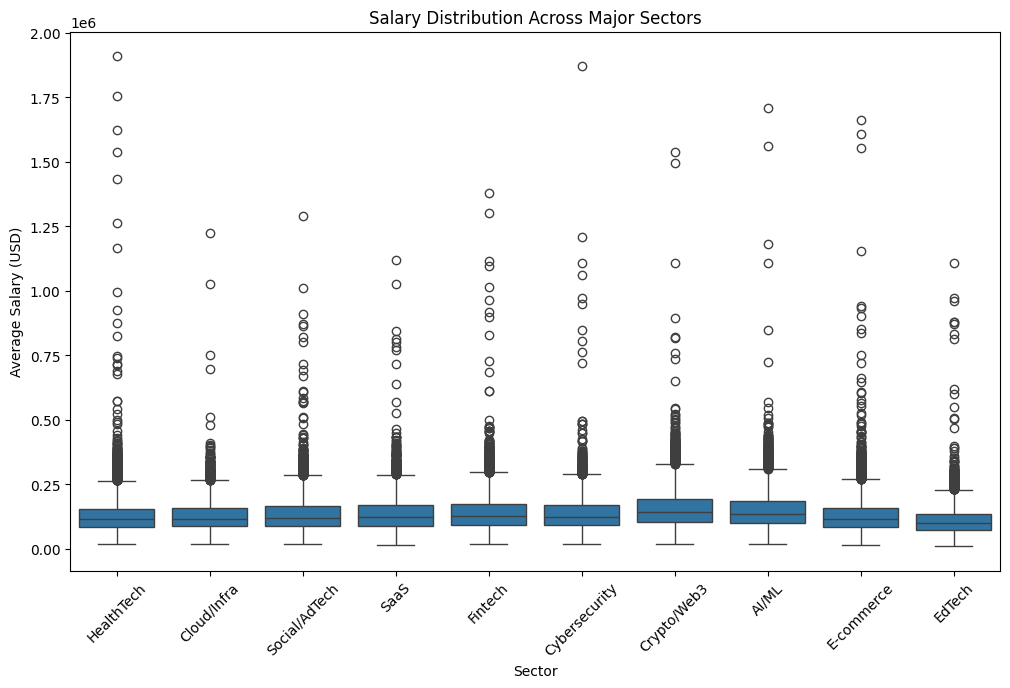

In [ ]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=sector_df,
    x='sector',
    y='avg_salary'
)

plt.title('Salary Distribution Across Major Sectors')
plt.xlabel('Sector')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45)

plt.show()

In [ ]:
sector_df.groupby('sector')['avg_salary'].agg(
    ['count', 'mean', 'median']
).round(2).sort_values('median', ascending=False)

,count,mean,median
sector,,,
Crypto/Web3,7593,153953.31,142050.0
AI/ML,8610,147137.77,134925.0
Fintech,12664,137648.0,126450.0
Cybersecurity,5491,137000.17,124150.0
SaaS,8185,132815.58,121850.0
Social/AdTech,8626,132506.83,120800.0
Cloud/Infra,6320,127036.05,116450.0
E-commerce,15962,125454.94,114200.0
HealthTech,14562,125177.16,113550.0


### Observation

Salary distributions were compared across the major sectors in the dataset. The results show differences in median salary and salary spread between sectors. Some sectors also contain noticeable salary outliers. This indicates that the sector of a job can be an important factor when comparing salary levels.


Seniority vs applicants

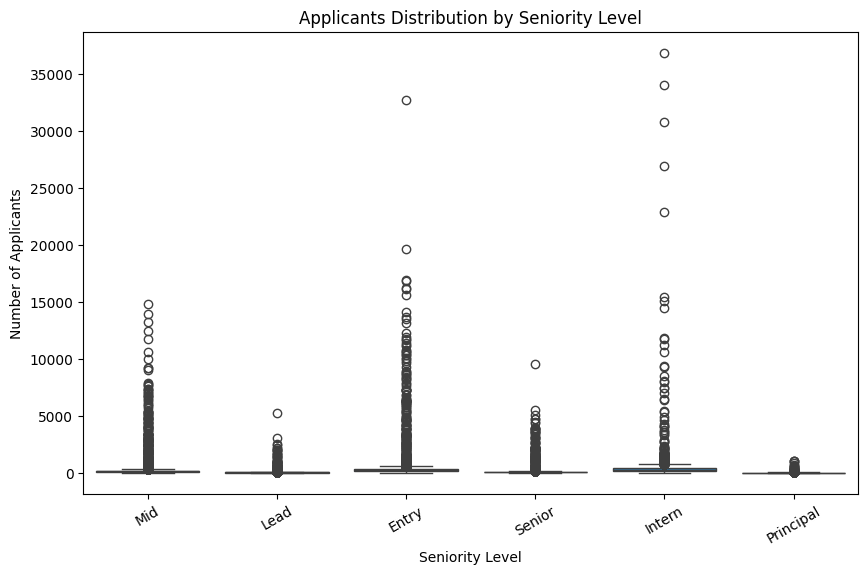

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='seniority_level',
    y='number_of_applicants'
)

plt.title('Applicants Distribution by Seniority Level')
plt.xlabel('Seniority Level')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=30)

plt.show()

In [ ]:
df.groupby('seniority_level')['number_of_applicants'].agg(
    ['count', 'mean', 'median']
).round(2)

,count,mean,median
seniority_level,,,
Entry,28337,290.15,214.0
Intern,9159,375.75,277.0
Lead,10370,46.56,34.0
Mid,38700,163.81,123.0
Principal,4526,24.01,18.0
Senior,22798,91.90,69.0


### Observation

The number of applicants was compared across different seniority levels. The distribution of applicants is not the same for all seniority categories, and some categories show a wider spread than others. Outliers are also present, indicating that some job postings received considerably more applications than others.


Interview round vs position status

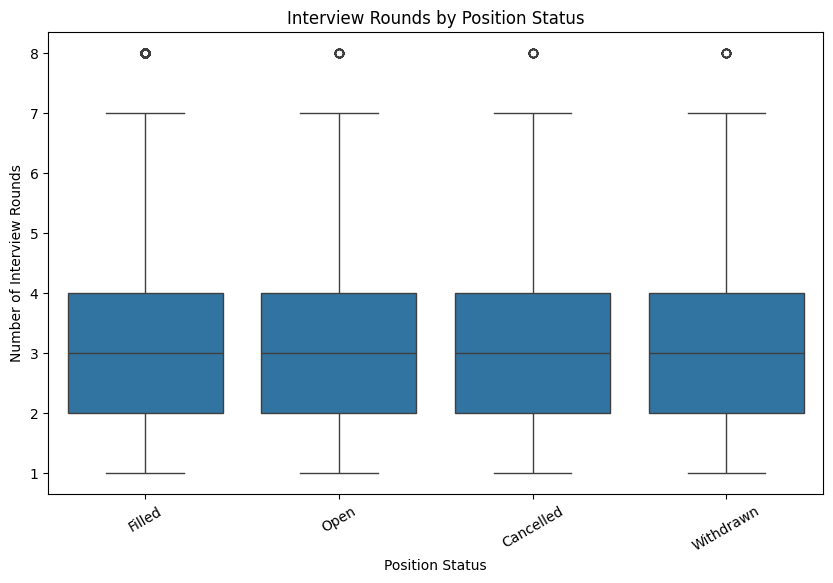

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='position_status',
    y='number_of_interview_rounds'
)

plt.title('Interview Rounds by Position Status')
plt.xlabel('Position Status')
plt.ylabel('Number of Interview Rounds')
plt.xticks(rotation=30)

plt.show()

In [ ]:
df.groupby('position_status')['number_of_interview_rounds'].agg(
    ['count', 'mean', 'median', 'max']
).round(2)

,count,mean,median,max
position_status,,,,
Cancelled,8026,3.32,3.0,8.0
Filled,90705,3.31,3.0,8.0
Open,10129,3.33,3.0,8.0
Withdrawn,5704,3.29,3.0,8.0


### Observation

The analysis compares the number of interview rounds with the current status of the job position. The number of interview rounds varies across different position-status categories. This provides an initial view of how the hiring process differs depending on whether a position is open, filled, or in another status.


Applicant vs salary

In [ ]:
plot_df = df[['number_of_applicants', 'avg_salary']].dropna()

plot_df = plot_df.sample(
    min(10000, len(plot_df)),
    random_state=42
)

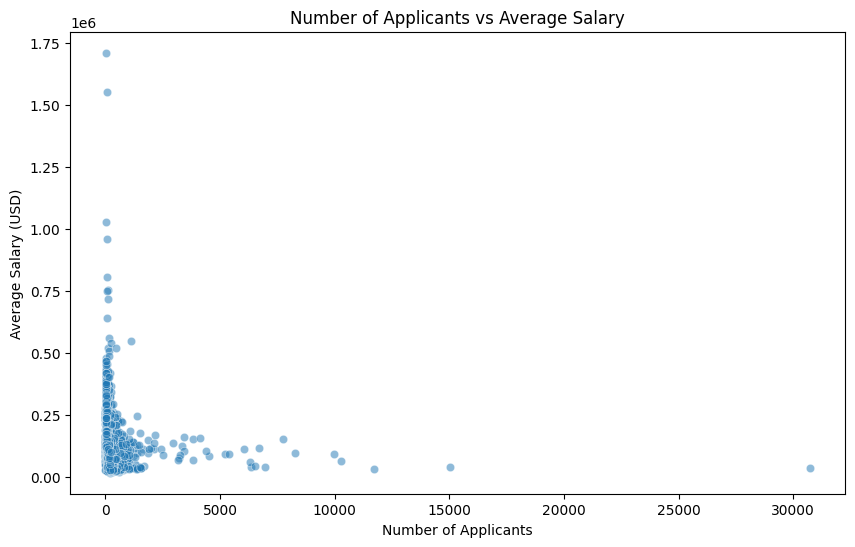

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x='number_of_applicants',
    y='avg_salary',
    alpha=0.5
)

plt.title('Number of Applicants vs Average Salary')
plt.xlabel('Number of Applicants')
plt.ylabel('Average Salary (USD)')

plt.show()

### Observation

The scatter plot was used to examine the relationship between the number of applicants and average salary. The points show considerable variation in salary and applicant counts, with no obvious strong linear pattern visible from the plot alone. The correlation value was also calculated to quantify the strength of their linear relationship.


MULTIVARIATE ANALYSIS

work mode vs seniority vs salary

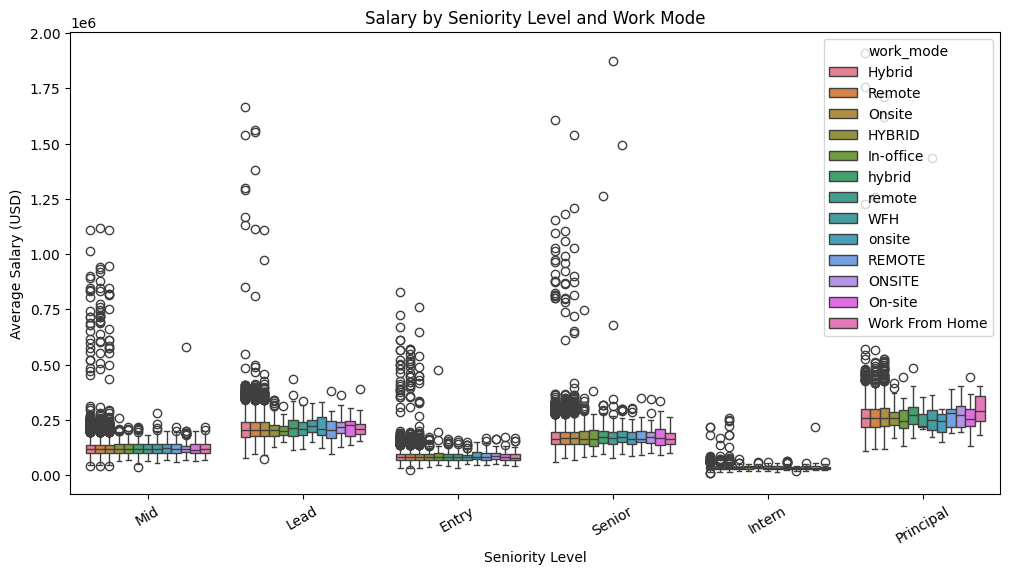

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='seniority_level',
    y='avg_salary',
    hue='work_mode'
)

plt.title('Salary by Seniority Level and Work Mode')
plt.xlabel('Seniority Level')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=30)

plt.show()

### Observation

Salary distribution was compared across seniority levels while also considering work mode.
The plot shows how salary varies across different combinations of seniority and work arrangement.
This provides a more detailed view than analysing seniority or work mode separately.

sector vs company type vs salary

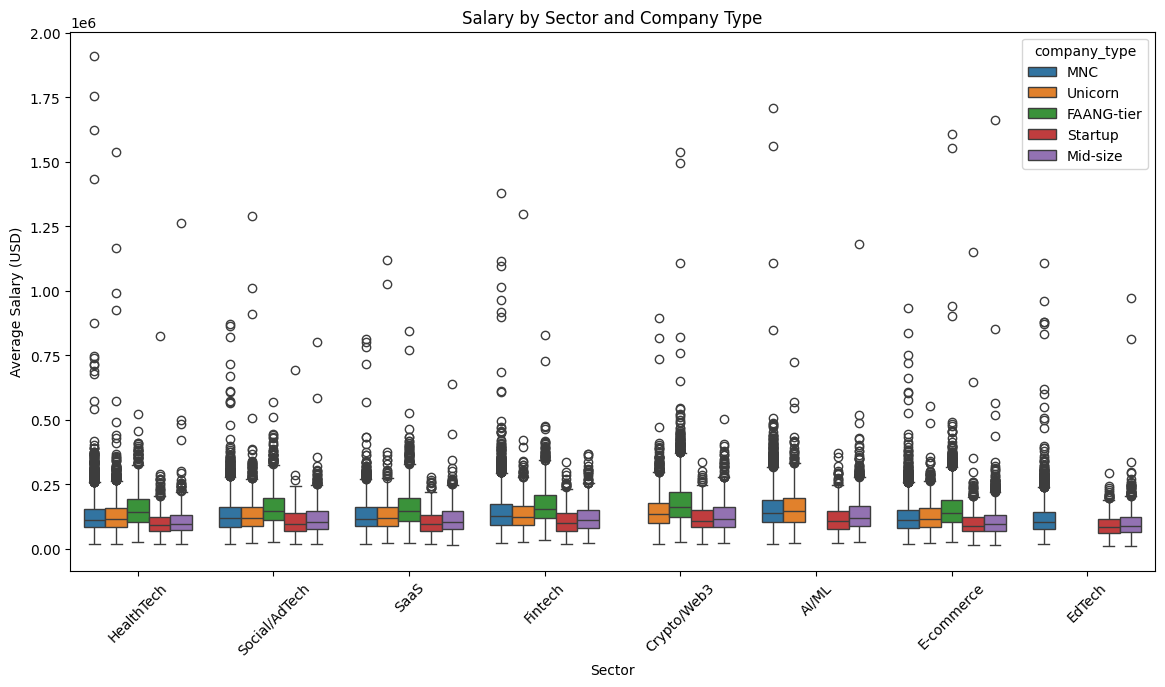

In [ ]:
top_sectors = df['sector'].value_counts().head(8).index

temp_df = df[df['sector'].isin(top_sectors)]

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=temp_df,
    x='sector',
    y='avg_salary',
    hue='company_type'
)

plt.title('Salary by Sector and Company Type')
plt.xlabel('Sector')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45)

plt.show()

### Observation

Salary was analysed across major sectors while also considering company type.
The results show that salary variation is influenced by more than one factor,
and differences can be observed between combinations of sectors and company types.

TIME BASED ANALYSIS

In [ ]:
df['posting_date'] = pd.to_datetime(df['posting_date'], errors='coerce')

In [ ]:
df['posting_year'] = df['posting_date'].dt.year

In [ ]:
yearly_postings = df['posting_year'].value_counts().sort_index()

print(yearly_postings)

posting_year
2019    11592
2020     9788
2021    13799
2022    13621
2023    10497
2024    19471
2025    20677
2026    15555
Name: count, dtype: int64


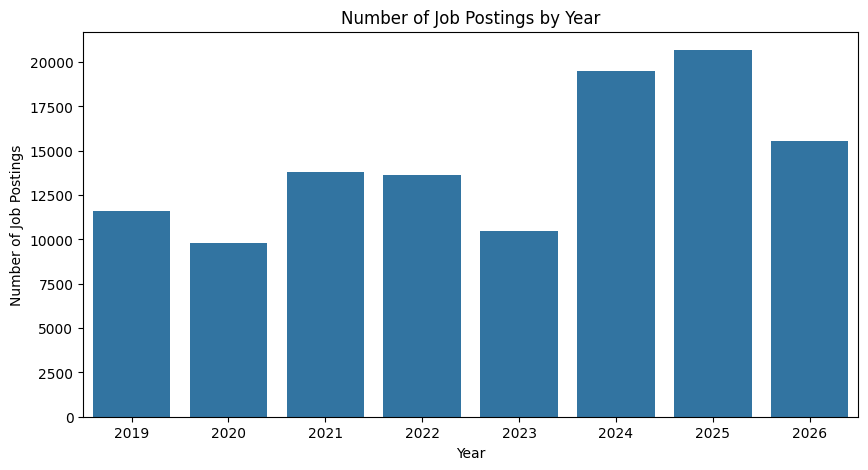

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=yearly_postings.index,
    y=yearly_postings.values
)

plt.title('Number of Job Postings by Year')
plt.xlabel('Year')
plt.ylabel('Number of Job Postings')

plt.show()

### Observation

The number of job postings varies across the years covered by the dataset.
The year-wise distribution helps identify periods with relatively higher or
lower job-posting activity.

Job posting by months

In [ ]:
df['posting_month'] = df['posting_date'].dt.month

In [ ]:
monthly_postings = df['posting_month'].value_counts().sort_index()

print(monthly_postings)

posting_month
1     12558
2     12569
3     10312
4      9781
5      9823
6      9701
7      9800
8      9853
9      8605
10     8675
11     8580
12     4743
Name: count, dtype: int64


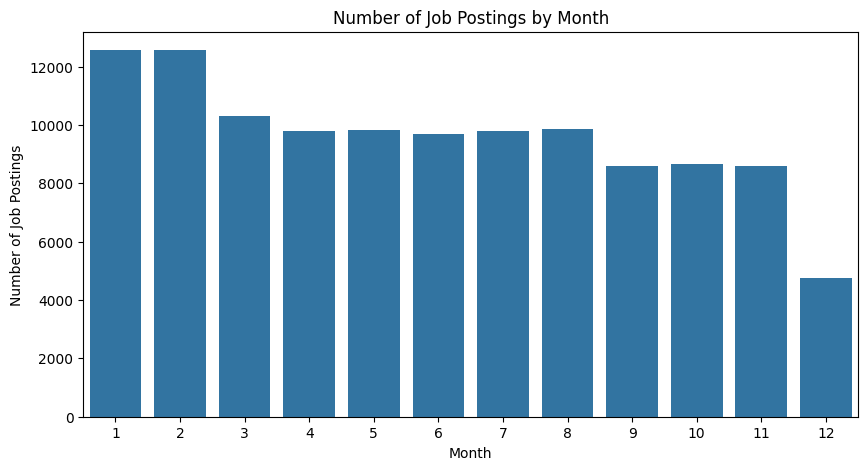

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=monthly_postings.index,
    y=monthly_postings.values
)

plt.title('Number of Job Postings by Month')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')

plt.show()

### Observation

Job postings are distributed across all months, although the number of
postings varies from month to month. This analysis helps identify whether
there are noticeable seasonal differences in hiring activity.

Salary trend over years

In [ ]:
yearly_salary = df.groupby('posting_year')['avg_salary'].agg(
    ['count', 'mean', 'median']
).round(2)

yearly_salary

,count,mean,median
posting_year,,,
2019,11070,128364.45,116800.0
2020,9412,129083.95,117775.0
2021,13247,128142.82,116700.0
2022,13083,129100.77,117500.0
2023,10035,129225.09,117400.0
2024,18668,130105.3,117950.0
2025,19812,129011.42,116950.0
2026,14932,128924.39,117325.0


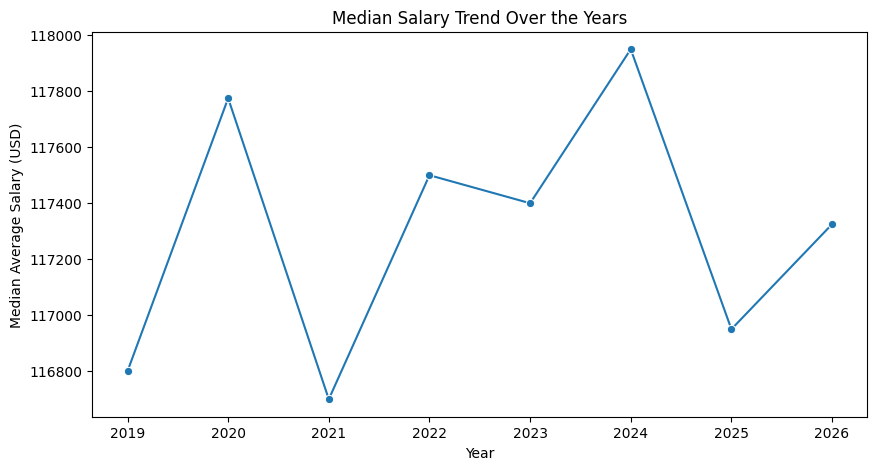

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=yearly_salary,
    x=yearly_salary.index,
    y='median',
    marker='o'
)

plt.title('Median Salary Trend Over the Years')
plt.xlabel('Year')
plt.ylabel('Median Average Salary (USD)')

plt.show()

### Observation

The yearly median salary shows how compensation levels have changed over
the period covered by the dataset. The trend indicates whether typical
salary levels have increased, decreased, or remained relatively stable
over time.

FEATURE ENGINEERING

In [ ]:

df['avg_salary'] = df[['salary_min_usd', 'salary_max_usd']].mean(axis=1)

In [ ]:
df[['salary_min_usd', 'salary_max_usd', 'avg_salary']].head(10)

,salary_min_usd,salary_max_usd,avg_salary
0,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>
2,238800.0,274700.0,256750.0
3,96300.0,104000.0,100150.0
4,186800.0,245400.0,216100.0
5,33100.0,38500.0,35800.0
6,87400.0,98100.0,92750.0
7,131100.0,103900.0,117500.0
8,114500.0,139700.0,127100.0
9,42500.0,47600.0,45050.0


In [ ]:
df['avg_salary'].describe()

,avg_salary
count,110259.0
mean,129051.768382
std,69741.823613
min,10300.0
25%,84750.0
50%,117300.0
75%,162000.0
max,1910150.0


The average salary is calculated from the minimum and maximum salary
values. It provides a single representative salary value for each
job posting.

In [ ]:
df['posting_date'] = pd.to_datetime(df['posting_date'], errors='coerce')
df['date_position_filled'] = pd.to_datetime(df['date_position_filled'], errors='coerce')

In [ ]:
df['time_to_fill_days'] = (
    df['date_position_filled'] - df['posting_date']
).dt.days

In [ ]:
df[['posting_date', 'date_position_filled', 'time_to_fill_days']].head(10)

,posting_date,date_position_filled,time_to_fill_days
0,2023-09-21,2023-11-20,60.0
1,2025-05-11,NaT,NaN
2,2025-12-01,2026-02-08,69.0
3,2020-11-21,2020-12-21,30.0
4,2025-07-03,2025-09-15,74.0
5,2025-08-08,2025-09-09,32.0
6,2022-04-18,2022-06-09,52.0
7,2024-04-19,2024-05-29,40.0
8,2022-04-05,2022-08-17,134.0
9,2025-04-25,2025-05-05,10.0


In [ ]:
print(
    "Negative time-to-fill values:",
    (df['time_to_fill_days'] < 0).sum()
)

Negative time-to-fill values: 445


In [ ]:
df['offer_accept_ratio'] = np.where(
    df['offers_extended'] > 0,
    df['offers_accepted'] / df['offers_extended'],
    np.nan
)

In [ ]:
df[['offers_extended', 'offers_accepted', 'offer_accept_ratio']].head(10)

,offers_extended,offers_accepted,offer_accept_ratio
0,5.0,5.0,1.000000
1,1.0,0.0,0.000000
2,1.0,1.0,1.000000
3,6.0,5.0,0.833333
4,1.0,1.0,1.000000
5,1.0,1.0,1.000000
6,1.0,3.0,3.000000
7,1.0,1.0,1.000000
8,1.0,1.0,1.000000
9,1.0,1.0,1.000000


In [ ]:
df['offer_accept_ratio'].describe()

,offer_accept_ratio
count,105037.000000
mean,0.948221
std,0.223816
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,3.000000


I calculated the difference between the position-filled date and posting date to understand how long companies take to fill positions

In [ ]:
df['offer_accept_ratio'] = np.where(
    df['offers_extended'] > 0,
    df['offers_accepted'] / df['offers_extended'],
    np.nan
)

In [ ]:
df[
    ['offers_extended',
     'offers_accepted',
     'offer_accept_ratio']
].head(10)

,offers_extended,offers_accepted,offer_accept_ratio
0,5.0,5.0,1.000000
1,1.0,0.0,0.000000
2,1.0,1.0,1.000000
3,6.0,5.0,0.833333
4,1.0,1.0,1.000000
5,1.0,1.0,1.000000
6,1.0,3.0,3.000000
7,1.0,1.0,1.000000
8,1.0,1.0,1.000000
9,1.0,1.0,1.000000


In [ ]:
print(
    "Ratios below 0:",
    (df['offer_accept_ratio'] < 0).sum()
)

print(
    "Ratios above 1:",
    (df['offer_accept_ratio'] > 1).sum()
)

Ratios below 0: 0
Ratios above 1: 550


The following features were created:

- `avg_salary` – average of minimum and maximum salary.
- `time_to_fill_days` – number of days between job posting and position filled.
- `offer_accept_ratio` – accepted offers divided by extended offers.


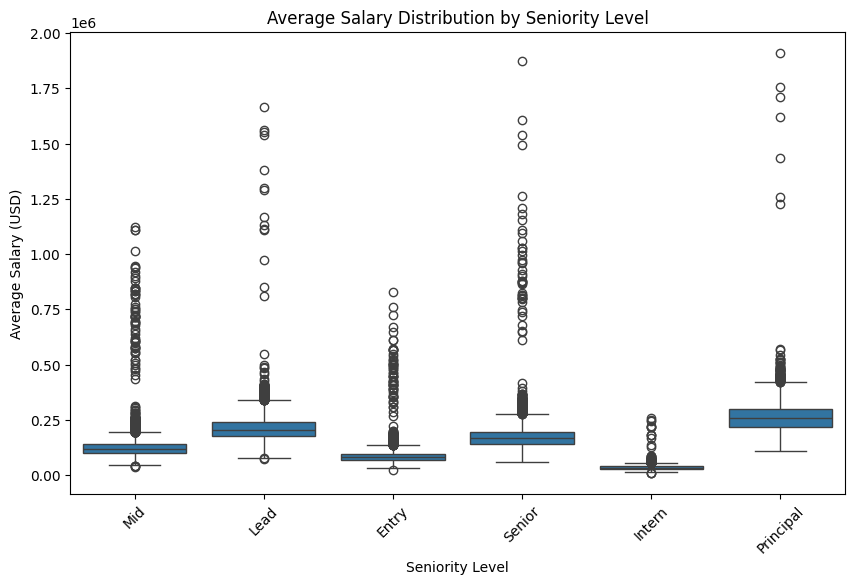

In [175]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='seniority_level',
    y='avg_salary'
)

plt.title('Average Salary Distribution by Seniority Level')
plt.xlabel('Seniority Level')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45)
plt.show()